# 07_dataset_bias_analysis

Phân tích các bias trong dataset: class imbalance, demographic bias, split bias, và temporal bias.

## 1. Import Libraries

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm
import re

## 2. Load Data

In [2]:
DATA_DIR = r"G:\My Drive\NCKH\A3Net-main\data\iu_xray"
ANN_PATH = os.path.join(DATA_DIR, "annotation.json")

with open(ANN_PATH, 'r') as f:
    data = json.load(f)

# Convert to DataFrame
records = []
for split_name in data.keys():
    for item in data[split_name]:
        records.append({
            "id": item['id'],
            "image_path": item['image_path'],
            "report": item['report'],
            "split": split_name
        })

df = pd.DataFrame(records)

print(f"Total samples: {len(df)}")
print(f"Train: {len(df[df['split']=='train'])}")
print(f"Val: {len(df[df['split']=='val'])}")
print(f"Test: {len(df[df['split']=='test'])}")

Total samples: 2955
Train: 2069
Val: 296
Test: 590


## 3. Class Imbalance Analysis

In [3]:
# Define disease keywords
diseases = [
    "atelectasis", "cardiomegaly", "consolidation", "edema",
    "effusion", "emphysema", "fibrosis", "hernia", "infiltration",
    "mass", "nodule", "pleural", "pneumonia", "pneumothorax"
]

# Count disease occurrences
disease_counts = {}
for d in diseases:
    disease_counts[d] = df["report"].str.contains(d, case=False).sum()

# Sort by count
disease_df = pd.DataFrame(list(disease_counts.items()), columns=['Disease', 'Count'])
disease_df = disease_df.sort_values('Count', ascending=False)
disease_df['Percentage'] = disease_df['Count'] / len(df) * 100

print("Disease Distribution:")
print(disease_df.to_string(index=False))

# Calculate imbalance ratio
imbalance_ratio = disease_df['Count'].max() / disease_df['Count'].min()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}")

Disease Distribution:
      Disease  Count  Percentage
     effusion   2291   77.529611
      pleural   2120   71.742809
 pneumothorax   2098   70.998308
consolidation    991   33.536379
  atelectasis    191    6.463621
       nodule    179    6.057530
        edema    175    5.922166
         mass    118    3.993232
 cardiomegaly    114    3.857868
    pneumonia    108    3.654822
    emphysema     66    2.233503
       hernia     34    1.150592
     fibrosis     10    0.338409
 infiltration      0    0.000000

Imbalance Ratio: inf


C:\Users\DANG KHOA\AppData\Local\Temp\ipykernel_40148\1161155936.py:22: RuntimeWarning: divide by zero encountered in scalar divide
  imbalance_ratio = disease_df['Count'].max() / disease_df['Count'].min()


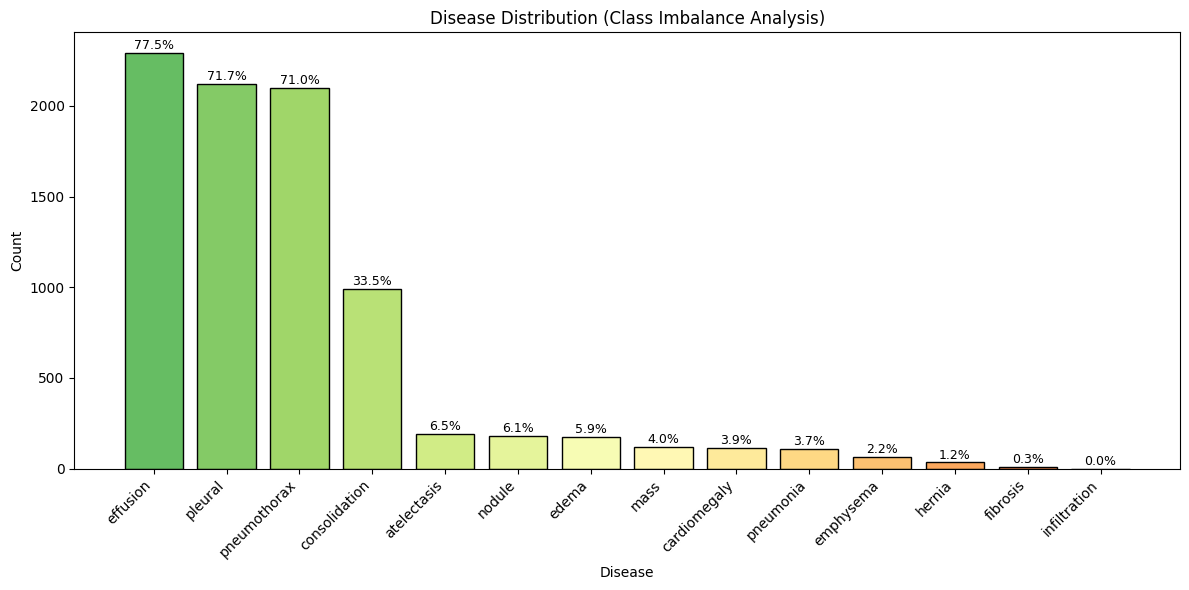

In [4]:
# Visualize disease distribution
plt.figure(figsize=(12, 6))

colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(disease_df)))

plt.bar(disease_df['Disease'], disease_df['Count'], color=colors, edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.title('Disease Distribution (Class Imbalance Analysis)')

# Add percentage labels
for i, (count, pct) in enumerate(zip(disease_df['Count'], disease_df['Percentage'])):
    plt.text(i, count + 20, f'{pct:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

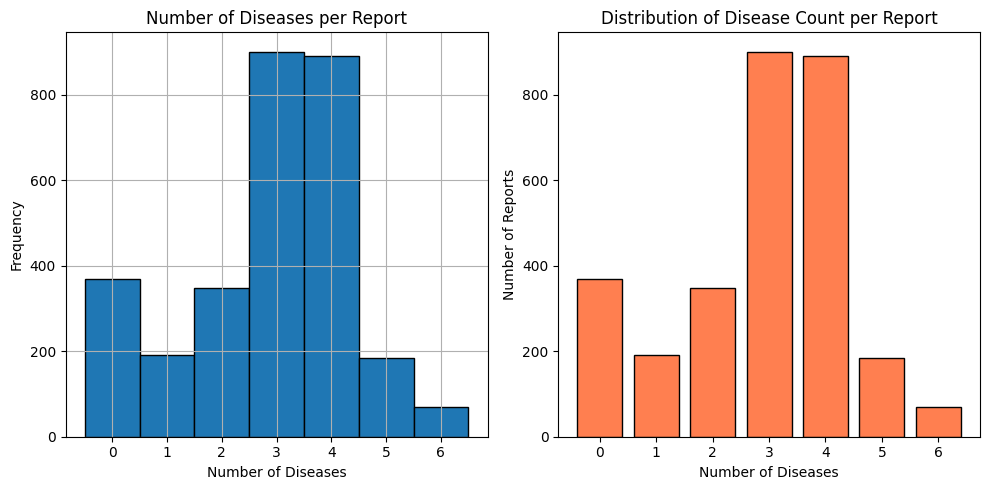


Disease count statistics:
count    2955.000000
mean        2.874788
std         1.501035
min         0.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         6.000000
Name: num_diseases, dtype: float64


In [5]:
# Multi-label analysis (number of diseases per report)
df['num_diseases'] = df['report'].apply(
    lambda x: sum(1 for d in diseases if d in x.lower())
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
df['num_diseases'].hist(bins=range(0, 8), edgecolor='black', align='left')
plt.title('Number of Diseases per Report')
plt.xlabel('Number of Diseases')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
disease_counts_per_report = df['num_diseases'].value_counts().sort_index()
plt.bar(disease_counts_per_report.index, disease_counts_per_report.values, edgecolor='black', color='coral')
plt.title('Distribution of Disease Count per Report')
plt.xlabel('Number of Diseases')
plt.ylabel('Number of Reports')

plt.tight_layout()
plt.show()

print(f"\nDisease count statistics:")
print(df['num_diseases'].describe())

## 4. Split Bias Analysis

In [6]:
# Check for data leakage (patient in multiple splits)
df['patient_id'] = df['id'].apply(lambda x: x.split('_')[0])

patient_split = df.groupby('patient_id')['split'].nunique()
leakage_patients = patient_split[patient_split > 1]

print("="*60)
print("SPLIT BIAS ANALYSIS")
print("="*60)

print(f"\n🔍 Data Leakage Check:")
print(f"   - Patients in multiple splits: {len(leakage_patients)}")
if len(leakage_patients) > 0:
    print(f"   - ⚠️ WARNING: Data leakage detected!")
else:
    print(f"   - ✅ No data leakage detected")

SPLIT BIAS ANALYSIS

🔍 Data Leakage Check:
   - Patients in multiple splits: 0
   - ✅ No data leakage detected


In [7]:
# Compare disease distribution across splits
split_disease_dist = {}

for split in ['train', 'val', 'test']:
    split_df = df[df['split'] == split]
    split_disease_dist[split] = {}
    for d in diseases:
        count = split_df['report'].str.contains(d, case=False).sum()
        split_disease_dist[split][d] = count / len(split_df) * 100

split_disease_df = pd.DataFrame(split_disease_dist)
print("\nDisease Distribution by Split (%):")
print(split_disease_df.round(2).to_string())


Disease Distribution by Split (%):
               train    val   test
atelectasis     6.77   5.07   6.10
cardiomegaly    4.06   5.41   2.37
consolidation  33.69  35.47  32.03
edema           6.04   5.07   5.93
effusion       77.14  80.41  77.46
emphysema       2.32   3.38   1.36
fibrosis        0.34   0.00   0.51
hernia          1.16   1.01   1.19
infiltration    0.00   0.00   0.00
mass            4.01   2.70   4.58
nodule          6.14   5.41   6.10
pleural        71.58  74.66  70.85
pneumonia       3.62   3.04   4.07
pneumothorax   69.99  76.01  72.03


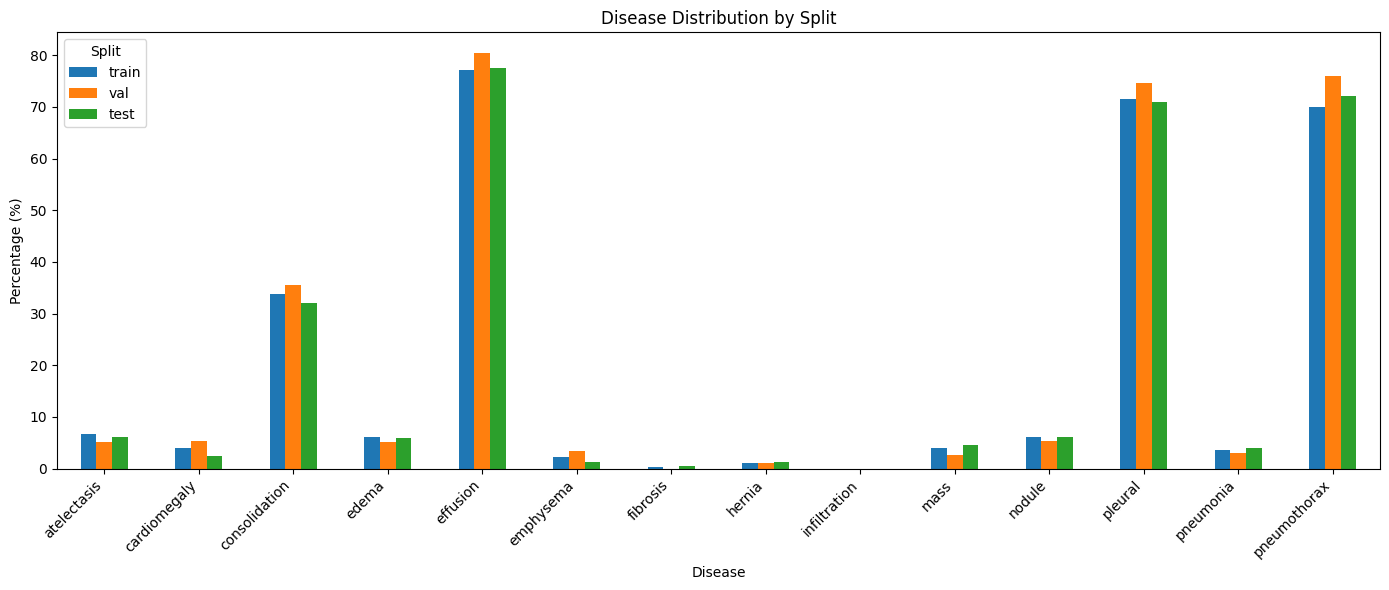

In [8]:
# Visualize disease distribution by split
split_disease_df.plot(kind='bar', figsize=(14, 6))
plt.title('Disease Distribution by Split')
plt.xlabel('Disease')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Split')
plt.tight_layout()
plt.show()

In [11]:
from scipy import stats
import numpy as np

contingency_table = []

for d in diseases:
    row = []
    for split in ['train', 'val', 'test']:
        split_df = df[df['split'] == split]
        count = split_df['report'].str.contains(d, case=False, na=False).sum()
        row.append(count)
    contingency_table.append(row)

contingency_table = np.array(contingency_table)

# remove empty rows
contingency_table = contingency_table[contingency_table.sum(axis=1) > 0]

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\n📊 Chi-Square Test for Disease Distribution:")
print(f"   - Chi-square statistic: {chi2:.4f}")
print(f"   - p-value: {p_value:.4f}")
print(f"   - Degrees of freedom: {dof}")

if p_value < 0.05:
    print(f"   - ⚠️ Significant difference in disease distribution across splits (p < 0.05)")
else:
    print(f"   - ✅ No significant difference in disease distribution across splits")


📊 Chi-Square Test for Disease Distribution:
   - Chi-square statistic: 16.5889
   - p-value: 0.8657
   - Degrees of freedom: 24
   - ✅ No significant difference in disease distribution across splits


## 5. Report Length Bias

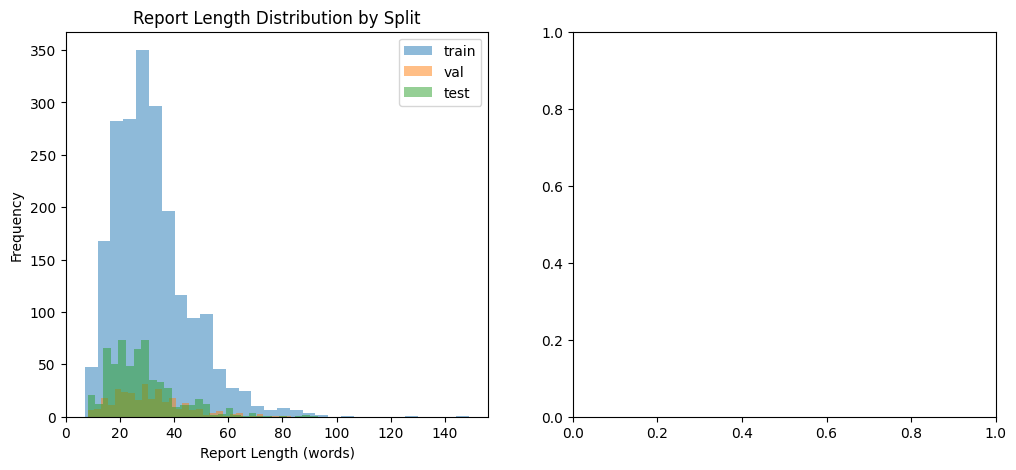

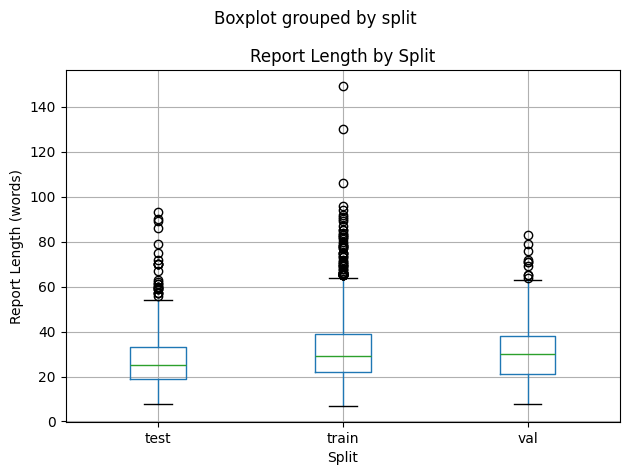


Report Length Statistics by Split:
        count       mean        std  min   25%   50%   75%    max
split                                                            
test    590.0  28.225424  13.180671  8.0  19.0  25.0  33.0   93.0
train  2069.0  31.773320  14.210845  7.0  22.0  29.0  39.0  149.0
val     296.0  31.128378  13.823478  8.0  21.0  30.0  38.0   83.0


In [12]:
# Analyze report length distribution across splits
df['report_length'] = df['report'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for split in ['train', 'val', 'test']:
    split_lengths = df[df['split'] == split]['report_length']
    plt.hist(split_lengths, bins=30, alpha=0.5, label=split)
plt.title('Report Length Distribution by Split')
plt.xlabel('Report Length (words)')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
df.boxplot(column='report_length', by='split')
plt.title('Report Length by Split')
plt.xlabel('Split')
plt.ylabel('Report Length (words)')

plt.tight_layout()
plt.show()

print("\nReport Length Statistics by Split:")
print(df.groupby('split')['report_length'].describe())

## 6. Negation Analysis (Important for Medical Reports)

In [13]:
# Negation detection
negation_patterns = [
    r'\bno\b', r'\bnot\b', r'\bnegative\b', 
    r'\bwithout\b', r'\babsence\b', r'\bclear\b'
]

def detect_negation(text):
    return any(re.search(p, text.lower()) for p in negation_patterns)

df['has_negation'] = df['report'].apply(detect_negation)

print("Negation Analysis:")
print(f"Total reports with negation: {df['has_negation'].sum()} ({df['has_negation'].mean()*100:.2f}%)")

# Negation by split
print("\nNegation by Split:")
for split in ['train', 'val', 'test']:
    split_df = df[df['split'] == split]
    negation_rate = split_df['has_negation'].mean() * 100
    print(f"   - {split}: {negation_rate:.2f}%")

Negation Analysis:
Total reports with negation: 2891 (97.83%)

Negation by Split:
   - train: 97.49%
   - val: 97.64%
   - test: 99.15%


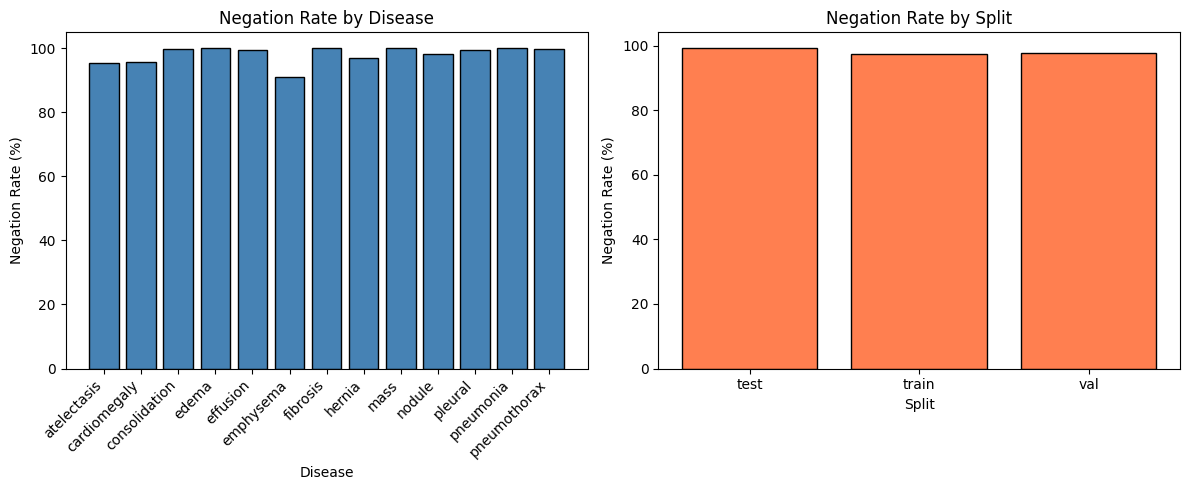

In [14]:
# Negation by disease
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
negation_by_disease = {}
for d in diseases:
    mask = df["report"].str.contains(d, case=False)
    with_negation = df[mask]['has_negation'].sum()
    total = mask.sum()
    if total > 0:
        negation_by_disease[d] = with_negation / total * 100

plt.bar(negation_by_disease.keys(), negation_by_disease.values(), color='steelblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.title('Negation Rate by Disease')
plt.xlabel('Disease')
plt.ylabel('Negation Rate (%)')

plt.subplot(1, 2, 2)
negation_by_split = df.groupby('split')['has_negation'].mean() * 100
plt.bar(negation_by_split.index, negation_by_split.values, color='coral', edgecolor='black')
plt.title('Negation Rate by Split')
plt.xlabel('Split')
plt.ylabel('Negation Rate (%)')

plt.tight_layout()
plt.show()

## 7. Vocabulary Bias

In [15]:
# Analyze vocabulary coverage across splits
def get_vocabulary(texts):
    words = []
    for text in texts:
        words.extend(text.lower().split())
    return set(words)

train_vocab = get_vocabulary(df[df['split'] == 'train']['report'])
val_vocab = get_vocabulary(df[df['split'] == 'val']['report'])
test_vocab = get_vocabulary(df[df['split'] == 'test']['report'])

print("Vocabulary Analysis:")
print(f"   - Train vocabulary size: {len(train_vocab)}")
print(f"   - Val vocabulary size: {len(val_vocab)}")
print(f"   - Test vocabulary size: {len(test_vocab)}")

# Check out-of-vocabulary words
val_oov = val_vocab - train_vocab
test_oov = test_vocab - train_vocab

print(f"\n   - Val OOV words: {len(val_oov)} ({len(val_oov)/len(val_vocab)*100:.2f}%)")
print(f"   - Test OOV words: {len(test_oov)} ({len(test_oov)/len(test_vocab)*100:.2f}%)")

Vocabulary Analysis:
   - Train vocabulary size: 2074
   - Val vocabulary size: 849
   - Test vocabulary size: 958

   - Val OOV words: 89 (10.48%)
   - Test OOV words: 113 (11.80%)


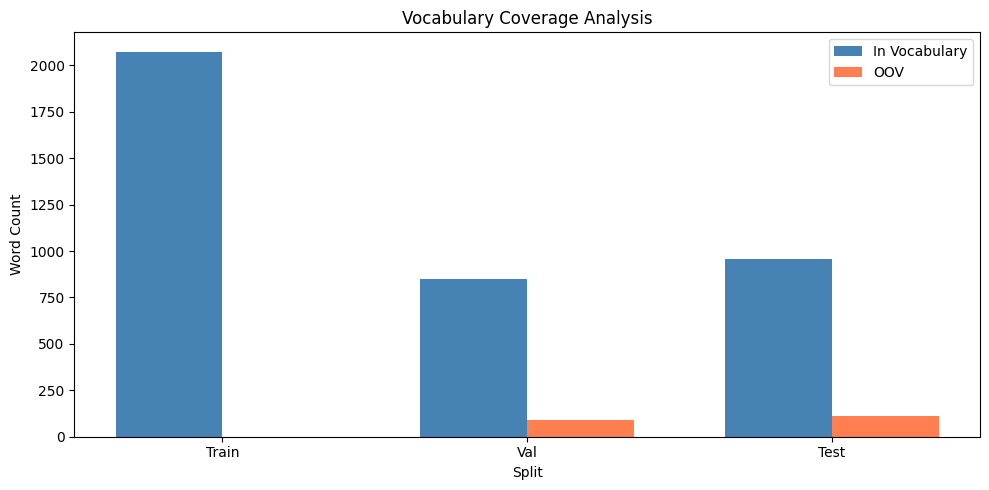

In [16]:
# Visualize OOV analysis
plt.figure(figsize=(10, 5))

vocab_data = {
    'Split': ['Train', 'Val', 'Test'],
    'Vocab Size': [len(train_vocab), len(val_vocab), len(test_vocab)],
    'OOV Count': [0, len(val_oov), len(test_oov)]
}

x = np.arange(3)
width = 0.35

plt.bar(x - width/2, vocab_data['Vocab Size'], width, label='In Vocabulary', color='steelblue')
plt.bar(x + width/2, vocab_data['OOV Count'], width, label='OOV', color='coral')

plt.xticks(x, vocab_data['Split'])
plt.title('Vocabulary Coverage Analysis')
plt.xlabel('Split')
plt.ylabel('Word Count')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Class Imbalance Solutions Analysis

In [17]:
# Calculate class weights for imbalanced dataset
print("="*60)
print("CLASS IMBALANCE SOLUTIONS")
print("="*60)

# Method 1: Inverse frequency weighting
total_samples = len(df)
class_weights = {}
max_count = max(disease_counts.values())

for disease, count in disease_counts.items():
    # Inverse frequency
    class_weights[disease] = total_samples / (len(diseases) * count) if count > 0 else 0

print("\n1. Inverse Frequency Class Weights:")
for disease, weight in sorted(class_weights.items(), key=lambda x: x[1], reverse=True):
    print(f"   - {disease}: {weight:.4f}")

# Method 2: Square root inverse
sqrt_weights = {}
for disease, count in disease_counts.items():
    sqrt_weights[disease] = np.sqrt(total_samples / (len(diseases) * count)) if count > 0 else 0

print("\n2. Square Root Inverse Weights:")
for disease, weight in sorted(sqrt_weights.items(), key=lambda x: x[1], reverse=True):
    print(f"   - {disease}: {weight:.4f}")

CLASS IMBALANCE SOLUTIONS

1. Inverse Frequency Class Weights:
   - fibrosis: 21.1071
   - hernia: 6.2080
   - emphysema: 3.1981
   - pneumonia: 1.9544
   - cardiomegaly: 1.8515
   - mass: 1.7887
   - edema: 1.2061
   - nodule: 1.1792
   - atelectasis: 1.1051
   - consolidation: 0.2130
   - pneumothorax: 0.1006
   - pleural: 0.0996
   - effusion: 0.0921
   - infiltration: 0.0000

2. Square Root Inverse Weights:
   - fibrosis: 4.5943
   - hernia: 2.4916
   - emphysema: 1.7883
   - pneumonia: 1.3980
   - cardiomegaly: 1.3607
   - mass: 1.3374
   - edema: 1.0982
   - nodule: 1.0859
   - atelectasis: 1.0512
   - consolidation: 0.4615
   - pneumothorax: 0.3172
   - pleural: 0.3155
   - effusion: 0.3035
   - infiltration: 0.0000


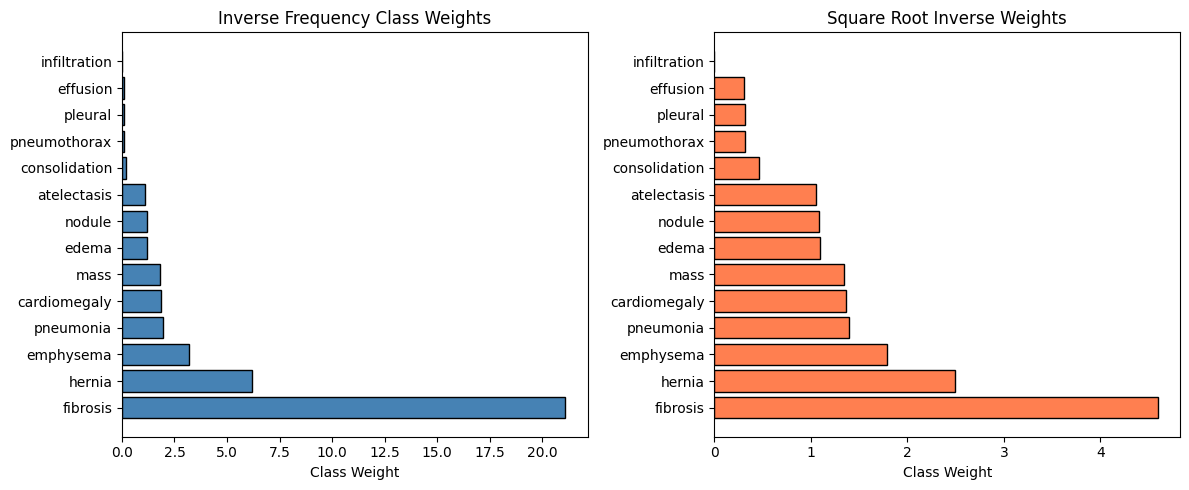

In [18]:
# Visualize class weights
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sorted_diseases = sorted(class_weights.keys(), key=lambda x: class_weights[x], reverse=True)
plt.barh(sorted_diseases, [class_weights[d] for d in sorted_diseases], color='steelblue', edgecolor='black')
plt.xlabel('Class Weight')
plt.title('Inverse Frequency Class Weights')

plt.subplot(1, 2, 2)
sorted_diseases_sqrt = sorted(sqrt_weights.keys(), key=lambda x: sqrt_weights[x], reverse=True)
plt.barh(sorted_diseases_sqrt, [sqrt_weights[d] for d in sorted_diseases_sqrt], color='coral', edgecolor='black')
plt.xlabel('Class Weight')
plt.title('Square Root Inverse Weights')

plt.tight_layout()
plt.show()

## 9. Summary Statistics

In [19]:
print("="*60)
print("DATASET BIAS ANALYSIS SUMMARY")
print("="*60)

print("\n📊 Class Imbalance:")
print(f"   - Most common disease: {disease_df.iloc[0]['Disease']} ({disease_df.iloc[0]['Percentage']:.2f}%)")
print(f"   - Least common disease: {disease_df.iloc[-1]['Disease']} ({disease_df.iloc[-1]['Percentage']:.2f}%)")
print(f"   - Imbalance ratio: {imbalance_ratio:.2f}")

print("\n🔍 Split Bias:")
print(f"   - Data leakage: {len(leakage_patients)} patients")
print(f"   - Chi-square p-value: {p_value:.4f}")

print("\n📝 Report Length:")
print(f"   - Mean length: {df['report_length'].mean():.2f} words")
print(f"   - Std length: {df['report_length'].std():.2f}")

print("\n⚠️ Negation:")
print(f"   - Reports with negation: {df['has_negation'].sum()} ({df['has_negation'].mean()*100:.2f}%)")

print("\n📚 Vocabulary:")
print(f"   - Train vocab: {len(train_vocab)}")
print(f"   - Val OOV: {len(val_oov)} ({len(val_oov)/len(val_vocab)*100:.2f}%)")
print(f"   - Test OOV: {len(test_oov)} ({len(test_oov)/len(test_vocab)*100:.2f}%)")

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)

DATASET BIAS ANALYSIS SUMMARY

📊 Class Imbalance:
   - Most common disease: effusion (77.53%)
   - Least common disease: infiltration (0.00%)
   - Imbalance ratio: inf

🔍 Split Bias:
   - Data leakage: 0 patients
   - Chi-square p-value: 0.8657

📝 Report Length:
   - Mean length: 31.00 words
   - Std length: 14.04

⚠️ Negation:
   - Reports with negation: 2891 (97.83%)

📚 Vocabulary:
   - Train vocab: 2074
   - Val OOV: 89 (10.48%)
   - Test OOV: 113 (11.80%)

ANALYSIS COMPLETE!
